In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

In [4]:
from pathlib import Path

print("Current directory:", Path.cwd())

for p in Path.cwd().rglob("behavioral_data.csv"):
    print("Found:", p.resolve())

Current directory: d:\NudgeIQ\notebooks


In [5]:
from pathlib import Path

for p in Path("..").rglob("behavioral_data.csv"):
    print(p.resolve())

D:\NudgeIQ\data\processed\behavioral_data.csv


In [6]:
import pandas as pd

df = pd.read_csv(r"D:\NudgeIQ\data\processed\behavioral_data.csv")

In [7]:
from pathlib import Path

file = Path(r"D:\NudgeIQ\data\processed\behavioral_data.csv")

print("Exists:", file.exists())
print("Is file:", file.is_file())
print("Absolute:", file.resolve())

Exists: True
Is file: True
Absolute: D:\NudgeIQ\data\processed\behavioral_data.csv


In [8]:
import pandas as pd

df = pd.read_csv(file)

print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [9]:
df = pd.read_csv(r"D:\NudgeIQ\data\processed\behavioral_data.csv")

print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [10]:
behavior = df.copy()

In [11]:
behavior["housing_num"] = behavior["housing"].map({"yes": 1, "no": 0})

behavior["loan_num"] = behavior["loan"].map({"yes": 1, "no": 0})

behavior["default_num"] = behavior["default"].map({"yes": 1, "no": 0})

behavior["deposit_num"] = behavior["deposit"].map({"yes": 1, "no": 0})

In [12]:
scaler = StandardScaler()

behavior["balance_z"] = scaler.fit_transform(
    behavior[["balance"]]
)

In [13]:
behavior["Financial_Stability"] = (
      0.60 * behavior["balance_z"]
    - 0.20 * behavior["housing_num"]
    - 0.15 * behavior["loan_num"]
    - 0.05 * behavior["default_num"]
)

In [14]:
behavior["Financial_Stability"] = scaler.fit_transform(
    behavior[["Financial_Stability"]]
)

In [15]:
behavior["Financial_Stability"].describe()

count    1.116200e+04
mean     1.018517e-17
std      1.000045e+00
min     -2.637114e+00
25%     -4.872739e-01
50%     -2.255599e-01
75%      1.189225e-01
max      2.397331e+01
Name: Financial_Stability, dtype: float64

In [16]:
education_map = {
    "primary": 0,
    "secondary": 1,
    "tertiary": 2,
    "unknown": 1
}

behavior["education_num"] = behavior["education"].map(education_map)

In [17]:
behavior["age_z"] = scaler.fit_transform(
    behavior[["age"]]
)

In [18]:
behavior["Investment_Readiness"] = (
      0.50 * behavior["Financial_Stability"]
    + 0.30 * behavior["education_num"]
    + 0.20 * behavior["age_z"]
)

behavior["Investment_Readiness"] = scaler.fit_transform(
    behavior[["Investment_Readiness"]]
)

In [19]:
behavior["Investment_Readiness"].describe()

count    1.116200e+04
mean     7.129617e-17
std      1.000045e+00
min     -1.920575e+00
25%     -5.781655e-01
50%     -1.501721e-01
75%      3.244338e-01
max      2.125539e+01
Name: Investment_Readiness, dtype: float64

In [20]:
contact_map = {
    "cellular": 2,
    "telephone": 1,
    "unknown": 0
}

behavior["contact_num"] = behavior["contact"].map(contact_map)

In [21]:
behavior["previous_z"] = scaler.fit_transform(
    behavior[["previous"]]
)

In [22]:
behavior["campaign_z"] = scaler.fit_transform(
    behavior[["campaign"]]
)

In [23]:
behavior["Digital_Engagement"] = (
      0.50 * behavior["contact_num"]
    + 0.30 * behavior["previous_z"]
    - 0.20 * behavior["campaign_z"]
)

behavior["Digital_Engagement"] = scaler.fit_transform(
    behavior[["Digital_Engagement"]]
)

In [24]:
behavior["Digital_Engagement"].describe()

count    1.116200e+04
mean    -6.111100e-17
std      1.000045e+00
min     -8.910644e+00
25%     -5.484718e-01
50%      2.907545e-01
75%      4.140815e-01
max      1.303346e+01
Name: Digital_Engagement, dtype: float64

In [25]:
behavior["Risk_Appetite"] = (
      0.45 * behavior["Financial_Stability"]
    + 0.35 * behavior["education_num"]
    - 0.20 * behavior["age_z"]
)

behavior["Risk_Appetite"] = scaler.fit_transform(
    behavior[["Risk_Appetite"]]
)

In [26]:
behavior["Risk_Appetite"].describe()

count    1.116200e+04
mean    -4.074067e-17
std      1.000045e+00
min     -2.353990e+00
25%     -5.425880e-01
50%     -9.367560e-02
75%      4.352658e-01
max      1.821445e+01
Name: Risk_Appetite, dtype: float64

In [27]:
behavior["Loyalty_Potential"] = (
      0.50 * behavior["previous_z"]
    + 0.30 * behavior["deposit_num"]
    + 0.20 * behavior["Financial_Stability"]
)

behavior["Loyalty_Potential"] = scaler.fit_transform(
    behavior[["Loyalty_Potential"]]
)

In [28]:
behavior["Loyalty_Potential"] = (
      0.50 * behavior["previous_z"]
    + 0.30 * behavior["deposit_num"]
    + 0.20 * behavior["Financial_Stability"]
)

behavior["Loyalty_Potential"] = scaler.fit_transform(
    behavior[["Loyalty_Potential"]]
)

In [29]:
behavior["Loyalty_Potential"].describe()

count    11162.000000
mean         0.000000
std          1.000045
min         -1.445032
25%         -0.635743
50%         -0.197844
75%          0.209041
max         21.267128
Name: Loyalty_Potential, dtype: float64

In [30]:
behavior["duration_z"] = scaler.fit_transform(
    behavior[["duration"]]
)

In [31]:
behavior["Responsiveness"] = (
      0.50 * behavior["duration_z"]
    + 0.30 * behavior["deposit_num"]
    - 0.20 * behavior["campaign_z"]
)

behavior["Responsiveness"] = scaler.fit_transform(
    behavior[["Responsiveness"]]
)

In [32]:
behavior["Responsiveness"].describe()

count    1.116200e+04
mean    -4.074067e-17
std      1.000045e+00
min     -7.855493e+00
25%     -6.699804e-01
50%     -1.481599e-01
75%      4.726655e-01
max      8.224426e+00
Name: Responsiveness, dtype: float64

In [33]:
behavior["Investment_Experience"] = (
      0.40 * behavior["age_z"]
    + 0.30 * behavior["previous_z"]
    + 0.30 * behavior["Financial_Stability"]
)

behavior["Investment_Experience"] = scaler.fit_transform(
    behavior[["Investment_Experience"]]
)

In [34]:
behavior["Investment_Experience"].describe()

count    11162.000000
mean         0.000000
std          1.000045
min         -1.681035
25%         -0.695598
50%         -0.195829
75%          0.453258
max         14.387261
Name: Investment_Experience, dtype: float64

In [35]:
behavior.to_csv(
    r"D:\NudgeIQ\data\processed\behavioral_features.csv",
    index=False
)

print("✅ behavioral_features.csv created successfully!")

✅ behavioral_features.csv created successfully!


In [36]:
constructs = [
    "Financial_Stability",
    "Investment_Readiness",
    "Digital_Engagement",
    "Risk_Appetite",
    "Loyalty_Potential",
    "Responsiveness",
    "Investment_Experience"
]

for col in constructs:
    behavior[col] = behavior[col].clip(-3, 3)

In [37]:
behavior[constructs].describe()

,Financial_Stability,Investment_Readiness,Digital_Engagement,Risk_Appetite,Loyalty_Potential,Responsiveness,Investment_Experience
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,-0.037309,-0.028615,-0.004267,-0.025719,-0.030983,-0.006420,-0.017703
std,0.710498,0.801378,0.946135,0.837476,0.802477,0.950339,0.904731
min,-2.637114,-1.920575,-3.000000,-2.353990,-1.445032,-3.000000,-1.681035
25%,-0.487274,-0.578165,-0.548472,-0.542588,-0.635743,-0.669980,-0.695598
50%,-0.225560,-0.150172,0.290755,-0.093676,-0.197844,-0.148160,-0.195829
75%,0.118923,0.324434,0.414081,0.435266,0.209041,0.472666,0.453258
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000


In [39]:
behavior.to_csv(
    r"D:\NudgeIQ\data\processed\behavioral_features.csv",
    index=False
)

print("✅ behavioral_features.csv saved successfully!")

✅ behavioral_features.csv saved successfully!


In [40]:
constructs = [
    "Financial_Stability",
    "Investment_Readiness",
    "Digital_Engagement",
    "Risk_Appetite",
    "Loyalty_Potential",
    "Responsiveness",
    "Investment_Experience"
]

behavior[constructs].corr().round(2)

,Financial_Stability,Investment_Readiness,Digital_Engagement,Risk_Appetite,Loyalty_Potential,Responsiveness,Investment_Experience
Financial_Stability,1.00,0.86,0.09,0.70,0.44,0.07,0.55
Investment_Readiness,0.86,1.00,0.13,0.62,0.41,0.06,0.70
Digital_Engagement,0.09,0.13,1.00,0.14,0.61,0.21,0.31
Risk_Appetite,0.70,0.62,0.14,1.00,0.33,0.05,0.02
Loyalty_Potential,0.44,0.41,0.61,0.33,1.00,0.26,0.63
Responsiveness,0.07,0.06,0.21,0.05,0.26,1.00,0.05
Investment_Experience,0.55,0.70,0.31,0.02,0.63,0.05,1.00


array([[<Axes: title={'center': 'Financial_Stability'}>,
        <Axes: title={'center': 'Investment_Readiness'}>,
        <Axes: title={'center': 'Digital_Engagement'}>],
       [<Axes: title={'center': 'Risk_Appetite'}>,
        <Axes: title={'center': 'Loyalty_Potential'}>,
        <Axes: title={'center': 'Responsiveness'}>],
       [<Axes: title={'center': 'Investment_Experience'}>, <Axes: >,
        <Axes: >]], dtype=object)

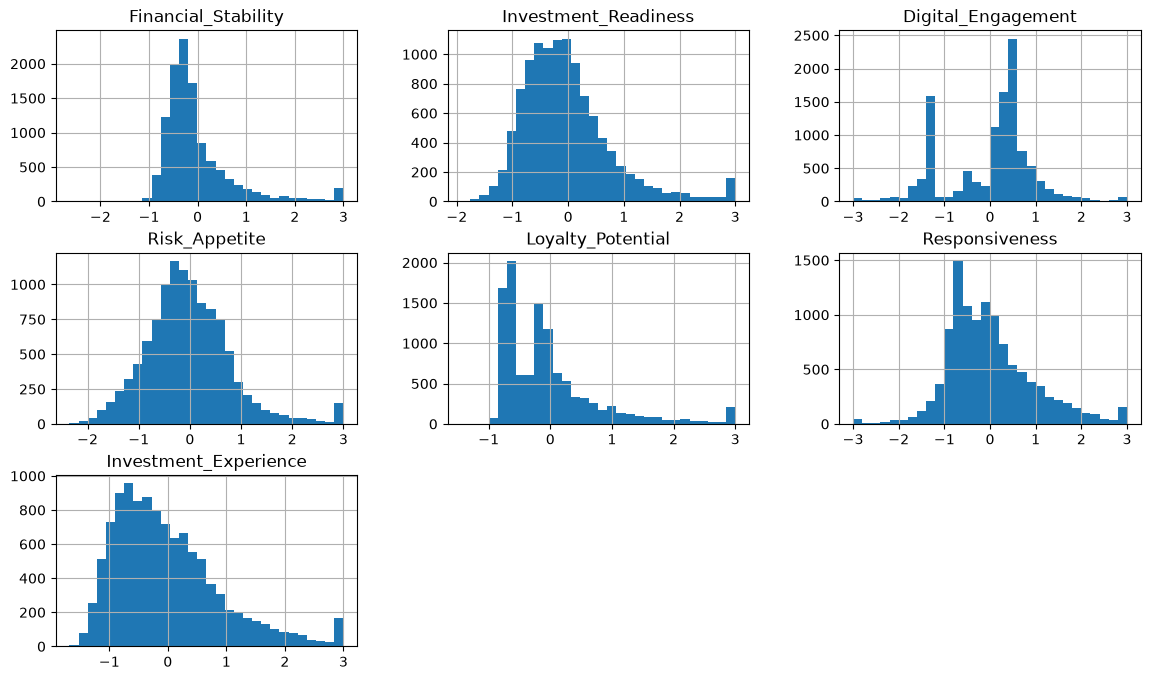

In [41]:
behavior[[
    "Financial_Stability",
    "Investment_Readiness",
    "Digital_Engagement",
    "Risk_Appetite",
    "Loyalty_Potential",
    "Responsiveness",
    "Investment_Experience"
]].hist(figsize=(14, 8), bins=30)